In [6]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'N')

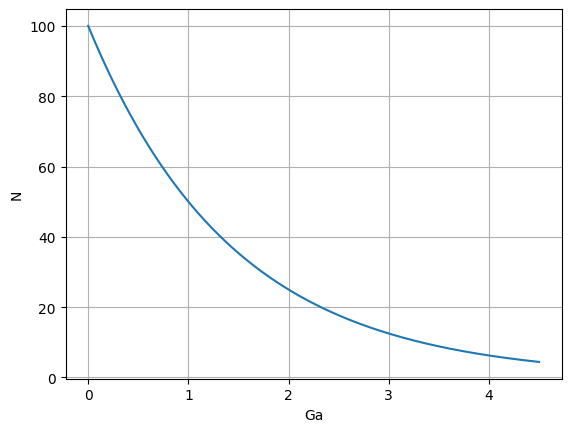

In [7]:
t = np.linspace(0.0,4.5E9,1000)

N0 = 100.0 # Quantidade inicial do isótopo instável

tau = 1.0E9 # meia-vida de 1 bilhão de anos

ln2 = np.log(2)

N = N0*np.exp(-t*ln2/tau)
plt.plot(t/1.0E9,N)
plt.grid()
plt.xlabel("Ga")
plt.ylabel("N")

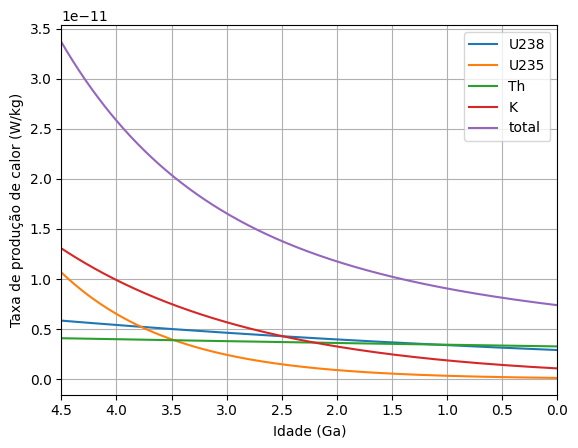

In [17]:
# -------------------------
# constantes (meias-vidas em anos)
# -------------------------
tau_U238 = 4.47e9
tau_U235 = 7.04e8
tau_Th232 = 1.40e10
tau_K40  = 1.25e9

# -------------------------
# Produção de calor (W/kg of isotope)
# -------------------------
H_U238 = 9.46e-5
H_U235 = 5.69e-4
H_Th232 = 2.64e-5
H_K40  = 2.92e-5

# -------------------------
# Abundância no manto terrestre (kg/kg manto)
# -------------------------
C_U = 31.0E-9
C_Th = 124.0E-9
C_K  = 36.9E-9


t = np.linspace(0,4.5E9,1000) # Idade

# -------------------------
# funções de decaimento
# -------------------------
U238 = C_U * 0.9927 * np.exp(t * ln2 / tau_U238)
U235 = C_U * 0.0072 * np.exp(t * ln2 / tau_U235)
Th232 = C_Th * np.exp(t * ln2 / tau_Th232)
K40  = C_K  * np.exp(t * ln2 / tau_K40)

plt.plot(t/1.0E9,U238*H_U238,label="U238")
plt.plot(t/1.0E9,U235*H_U235,label="U235")
plt.plot(t/1.0E9,Th232*H_Th232,label="Th")
plt.plot(t/1.0E9,K40*H_K40,label="K")

H = U238*H_U238 + U235*H_U235 + Th232*H_Th232 + K40*H_K40

plt.plot(t/1.0E9,H,label="total")

plt.ylabel("Taxa de produção de calor (W/kg)")
plt.xlabel("Idade (Ga)")

plt.legend()

plt.xlim(4.5,0)
plt.grid()


In [28]:
print(H[0],"W/kg")

7.38927282e-12 W/kg


In [32]:
MM = 4.0E24 # Massa do manto em kg

Pot = MM*H[0]

print(Pot/1.0E12,"TW")

29.557091279999995 TW


In [34]:
R = 6_371_000.0
A = 4*np.pi*R**2

q = Pot/A
print(q*1000,"mW/m2")

57.947755446153806 mW/m2


In [35]:
Ac = A*0.29 # Area dos continentes como sendo 29% da área total
hc = 25_000.0 # Espessura efetiva produtora de calor radiogenico

V = Ac*hc # Volume efetivo da crosta continental

Hc = H[0]*100 # Produçao de calor radiogenico na crosta W/kg

rhoc = 2700.0

Mc = rhoc*V

Potc = Mc*Hc

print(Potc/1.0E12,"TW")


7.377828342065251 TW


In [36]:
Pot_total = 47.0E12 # Fluxo total de calor da Terra

print(Pot/Pot_total)

0.6288742825531914


In [37]:
print(Potc/Pot_total)

0.15697507110777129


In [38]:
print((Pot+Potc)/1.0E12)

36.93491962206525
